# Práctica 3 parte 1
## Valentina Acevedo Mesa - 1000763409
## Juan José Garcés Rojas - 1007409305

In [46]:
#librerias necesarias para el desarrolo de la práctica
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import pandas as pd
from scipy.stats import shapiro
from scipy.stats import levene
from scipy.stats import mannwhitneyu
from scipy.stats import spearmanr
from statsmodels.tsa.stattools import adfuller

#punto 1
Lo Segundo que debemoa hacer luego de importar las librerías necesarias es leer el archivo .mat, esto lo vamos a hacer mediante la librería scipy, además de imprimen en pantalla los primeros valores del archivo para ver las variables que tiene el mismo y se observa el tamaño mediante shape.

In [14]:
# Cargar archivo .mat
data = sio.loadmat("signals.mat")

# Ver qué variables contiene para saber cuales exportar
print(data.keys())

#verificar el tamaño del arreglo
raw = data['ECG_asRecording']
print(raw.shape)

dict_keys(['__header__', '__version__', '__globals__', 'Fs', 'ECG_asRecording', 'ECG_filtered', 'EMG_filtered1', 'EMG_filtered2', 'EMG_asRecording1', 'EMG_asRecording2'])
(1, 30720)


Teniendo en cuenta que la frecuencia de muestreo fue Fs=1024Hz y sabiendo también el número total de muestras se puede calcular el tiempo y por tanto el crear el vector de tiempo necesario para el desarrolo de la práctica como T= N/Fs

In [4]:
#creación del vector de tiempo.
Fs = data["Fs"][0][0]
ecg = data["ECG_asRecording"].flatten() #el flatten 'aplana los datos'

# Número de muestras
N = len(ecg)

# Duración total de la señal
duracion = N / Fs

print("Frecuencia de muestreo:", Fs, "Hz")
print("Número de muestras:", N)
print("Duración de la señal:", duracion, "segundos")

# Crear vector de tiempo
t = np.arange(0, N) / Fs

Frecuencia de muestreo: 1024 Hz
Número de muestras: 30720
Duración de la señal: 30.0 segundos


#punto 2

gráfica de la señal sin filtrar vs la señal filtrada.

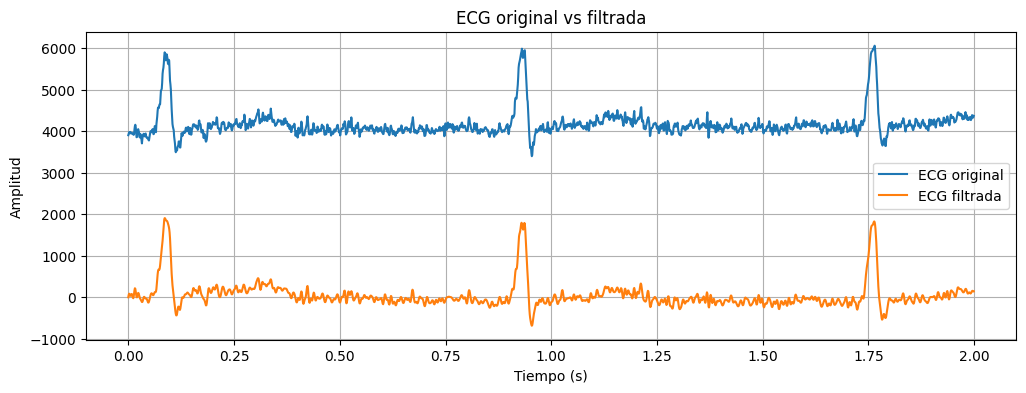

In [5]:
ecg_cruda = data["ECG_asRecording"].flatten()
ecg_filtrada = data["ECG_filtered"].flatten()

#para ver los datos los primeros 2 segundos
muestras_2s = int(2*Fs) #permite ver las muestras de los 2 primeros segundos

#Cortar cada uno de los vectores de interes para visualizar solo las muestras de 2 segundos
tiempo_2 = t[:muestras_2s]
original_ECG2 = ecg_cruda[:muestras_2s]
filtrada_ECG2 = ecg_filtrada[:muestras_2s]

plt.figure(figsize=(12,4))
plt.plot(tiempo_2, original_ECG2, label="ECG original")
plt.plot(tiempo_2, filtrada_ECG2, label="ECG filtrada")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.title("ECG original vs filtrada")
plt.grid()
plt.legend()
plt.show()

Lo primero que se hace es graficar las señales solo los dos primeros segundos, esto debido a que cuando se grafica toda la señal no se pueden observar características necesarias  para el posterior análisis.
Teniendo en cuenta la versión estándar de un ecg, podemos ver como los complejos QRS que corresponden a los latidos cardiacos están en un rango de 4000 a 6000 en la señal original mientras que en la señal fuiltrada se establecen en rangos de 0 a 2000, esto se puede explicar mediante un filtro que atenúe los componentes de baja frecuencia responsables de los desplazamientos de la línea base del ecg y este es un comportamiento típico de un filtro pasa-altas.


Teniendo en cuenta que las frecuencias típicas de un ecg son de 1 Hz a 80 Hz (en una persona con 60 a 90 latidos por minuto) el comportamiendo del filtro es correcto.
Todo esto nos deja ver como en dos segundos hay un total de 3 picos correspondientes a latidos y haciendo la conversión a valores conocidos y asumiendo que el comportamiendo sigue siendo igual en el resto de la señal, la señal tendría 90 latidos por minuto lo que corresponde a una persona sana.[1]

# punto 3
gráfica de un ciclo cardiaco y valores estadísticos

/tmp/ipykernel_1102/507002456.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


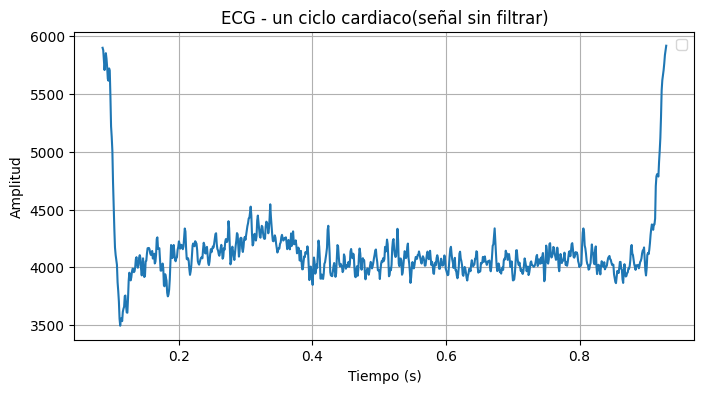

Resultados estadísticos del ciclo cardiaco para la señal sin filtrar:
Promedio: 4131.136
RMS: 4142.455
Varianza: 93646.222
Desviación estándar: 306.017


In [20]:
#Para la señal original
peaks, _ = find_peaks(ecg_cruda, distance=int(0.6*Fs)) #se establece una distancia para que no se grafiquen solo 2 puntos

ciclo = ecg_cruda[peaks[0]:peaks[1]]
tiempo_picos = t[peaks[0]:peaks[1]]

plt.figure(figsize=(8,4))
plt.plot(tiempo_picos, ciclo)
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.title("ECG - un ciclo cardiaco(señal sin filtrar)")
plt.legend()
plt.grid(True)
plt.show()
# Promedio
media = np.mean(ciclo)
# RMS
rms = np.sqrt(np.mean(ciclo**2))
# Varianza
varianza = np.var(ciclo)
# Desviación estándar
desv_std = np.std(ciclo)

print(f"""Resultados estadísticos del ciclo cardiaco para la señal sin filtrar:
Promedio: {media:.3f}
RMS: {rms:.3f}
Varianza: {varianza:.3f}
Desviación estándar: {desv_std:.3f}""")

El ciclo cardiaco fue seleccionado entre dos picos R consecutivos del complejo QRS mediante peaks.
El ciclo cardiaco seleccionado muestra claramente las principales características de la señal ECG, incluyendo el complejo QRS y las ondas asociadas al ciclo eléctrico del corazón. Los parámetros estadísticos calculados permiten describir cuantitativamente la señal, donde el valor RMS refleja la magnitud efectiva del ciclo, mientras que la varianza y la desviación estándar indican la dispersión de los valores alrededor del promedio.

Los resultados de los valores estadísticos muestran que el promedio que es un valor medio de las muestras del ciclo es muy alto (4131) esto es debido a que la señal aún no está filtrada y contiene componentes con offset o un componente DC que es común en sistemas de adquisición con conversones analógicos digitales

En cuanto al valor RMS es un valor cercano al promedio, esto es esperado debido a que el cálculo considera el cuadrado de la señal que refleja la magnitud efectiva, entonces la cercanía de los datos indica que la señal oscila al rededor de un valor medio relativamente estable.

La varianza que es la encargada de medir la dispersión de los datos respecto al promedio, al mostrar también un valor muy alto indica que los valores son muy poco compactos y se encuentran dispersos respecto al valor promedio.

Por último la desviación estándar es la magnitud del promedio de las fluctuaciones respecto a la media también es un valor elevado.

El conjunto de resultados sin necesidad de ver las gráficas nos permite intuir que hay algo deficiente, es decir, en este caso las estadística descriptiva nos da indicios de buscar algún error o tener alguna variable que no es tenida en cuenta debido a que los datos están muy dispersos. En este caso por literatura sabemos que muy probablemente la señal tenga un offset grande propio de sistemas de adquisición y esto es común en estos tipos de dispositivos.[2],[3]

# Punto 4
mismo punto 3 pero para la señal filtrada

/tmp/ipykernel_1102/2186888056.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


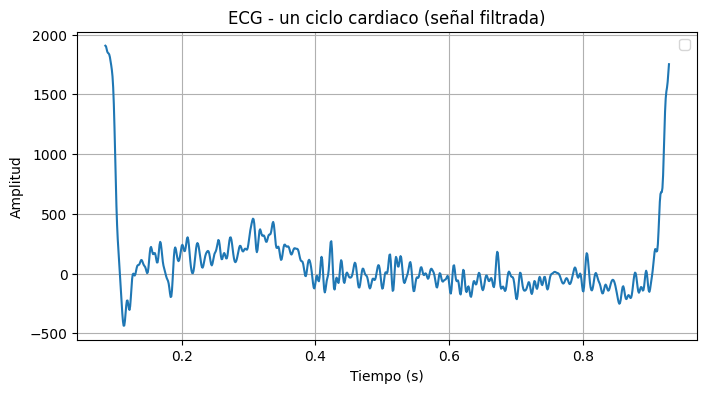

Resultados estadísticos del ciclo cardiaco para la señal filtrada:
Promedio: 74.010
RMS: 319.628
Varianza: 96684.315
Desviación estándar: 310.941


In [21]:
#Para la señal filtrada
peaks, _ = find_peaks(ecg_filtrada, distance=int(0.6*Fs)) #se establece una distancia para que no se grafiquen solo 2 puntos

ciclo2 = ecg_filtrada[peaks[0]:peaks[1]]
tiempo_picos2 = t[peaks[0]:peaks[1]]

plt.figure(figsize=(8,4))
plt.plot(tiempo_picos2, ciclo2)
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.title("ECG - un ciclo cardiaco (señal filtrada)")
plt.legend()
plt.grid(True)
plt.show()
# Promedio
media = np.mean(ciclo2)
# RMS
rms = np.sqrt(np.mean(ciclo2**2))
# Varianza
varianza = np.var(ciclo2)
# Desviación estándar
desv_std = np.std(ciclo2)

print(f"""Resultados estadísticos del ciclo cardiaco para la señal filtrada:
Promedio: {media:.3f}
RMS: {rms:.3f}
Varianza: {varianza:.3f}
Desviación estándar: {desv_std:.3f}""")

Los datos de la señal filtrada para el mismo ciclo cambian notablemente, por ejemplo el promedio se reduce drástricamente de 3131 a 74, esto indica que el proceso de filtrado eliminó eficazmente el offset que presentaba la señal original, este comportamiento es típico de un filtro pasa-altas que son diseñados para remover el corrimiento de la línea base de la señal.

El valor RMS también disminuye considerablemente en comparación con  la señal original. Esto sugiere que el filtrado redujo componentes de ruido presentes en la señal sin procesar, especialmente aquellas asociadas a frecuencias fuera de rango.

Por otro lado, la varianza y la desviación estándar permanecen en valores similares a los de la señal original y esto debido a que el filtrado busca mantener la variabilidad propia de la señal ECG puesto estos componentes son en muchos casos importantes para el análisis clínico.



Teniendo en cuenta los dos análisis estadísticos podemos concluir que el filtro hace muy bien su trabajo puesto que elimina valores que no son deseados para un posterior análisis clínico pero sin eliminar componentes vitales de la señal.

# punto 5
Análisis de 15 ciclos.

In [32]:
if len(peaks) < 16:
    print("No hay suficientes picos detectados para extraer 15 ciclos.")
else:
    ciclos = []
    tiempos_ciclos = []
    promedios = []
    varianzas = []

    for i in range(15):
        ciclo = ecg_filtrada[peaks[i]:peaks[i+1]]
        tiempo_ciclo = t[peaks[i]:peaks[i+1]]

        ciclos.append(ciclo)
        tiempos_ciclos.append(tiempo_ciclo)
        promedios.append(np.mean(ciclo))
        varianzas.append(np.var(ciclo))

    tabla= pd.DataFrame({'Ciclo': np.arange(1,16), 'Promedio': promedios, 'Varianza': varianzas})
    tabla= tabla.round(3)
    print(tabla)

    Ciclo  Promedio    Varianza
0       1    74.010   96684.315
1       2    -1.463  104790.465
2       3   -10.433   82451.251
3       4   -20.975   46839.020
4       5    40.871  114850.020
5       6   -27.944   58147.590
6       7     0.431   77707.281
7       8    21.408  100268.182
8       9   -10.175   71784.956
9      10     8.812   68481.060
10     11    -8.906   76088.385
11     12    13.213   93862.696
12     13    -4.203   87951.504
13     14   -14.970   77022.133
14     15    27.108   89636.936


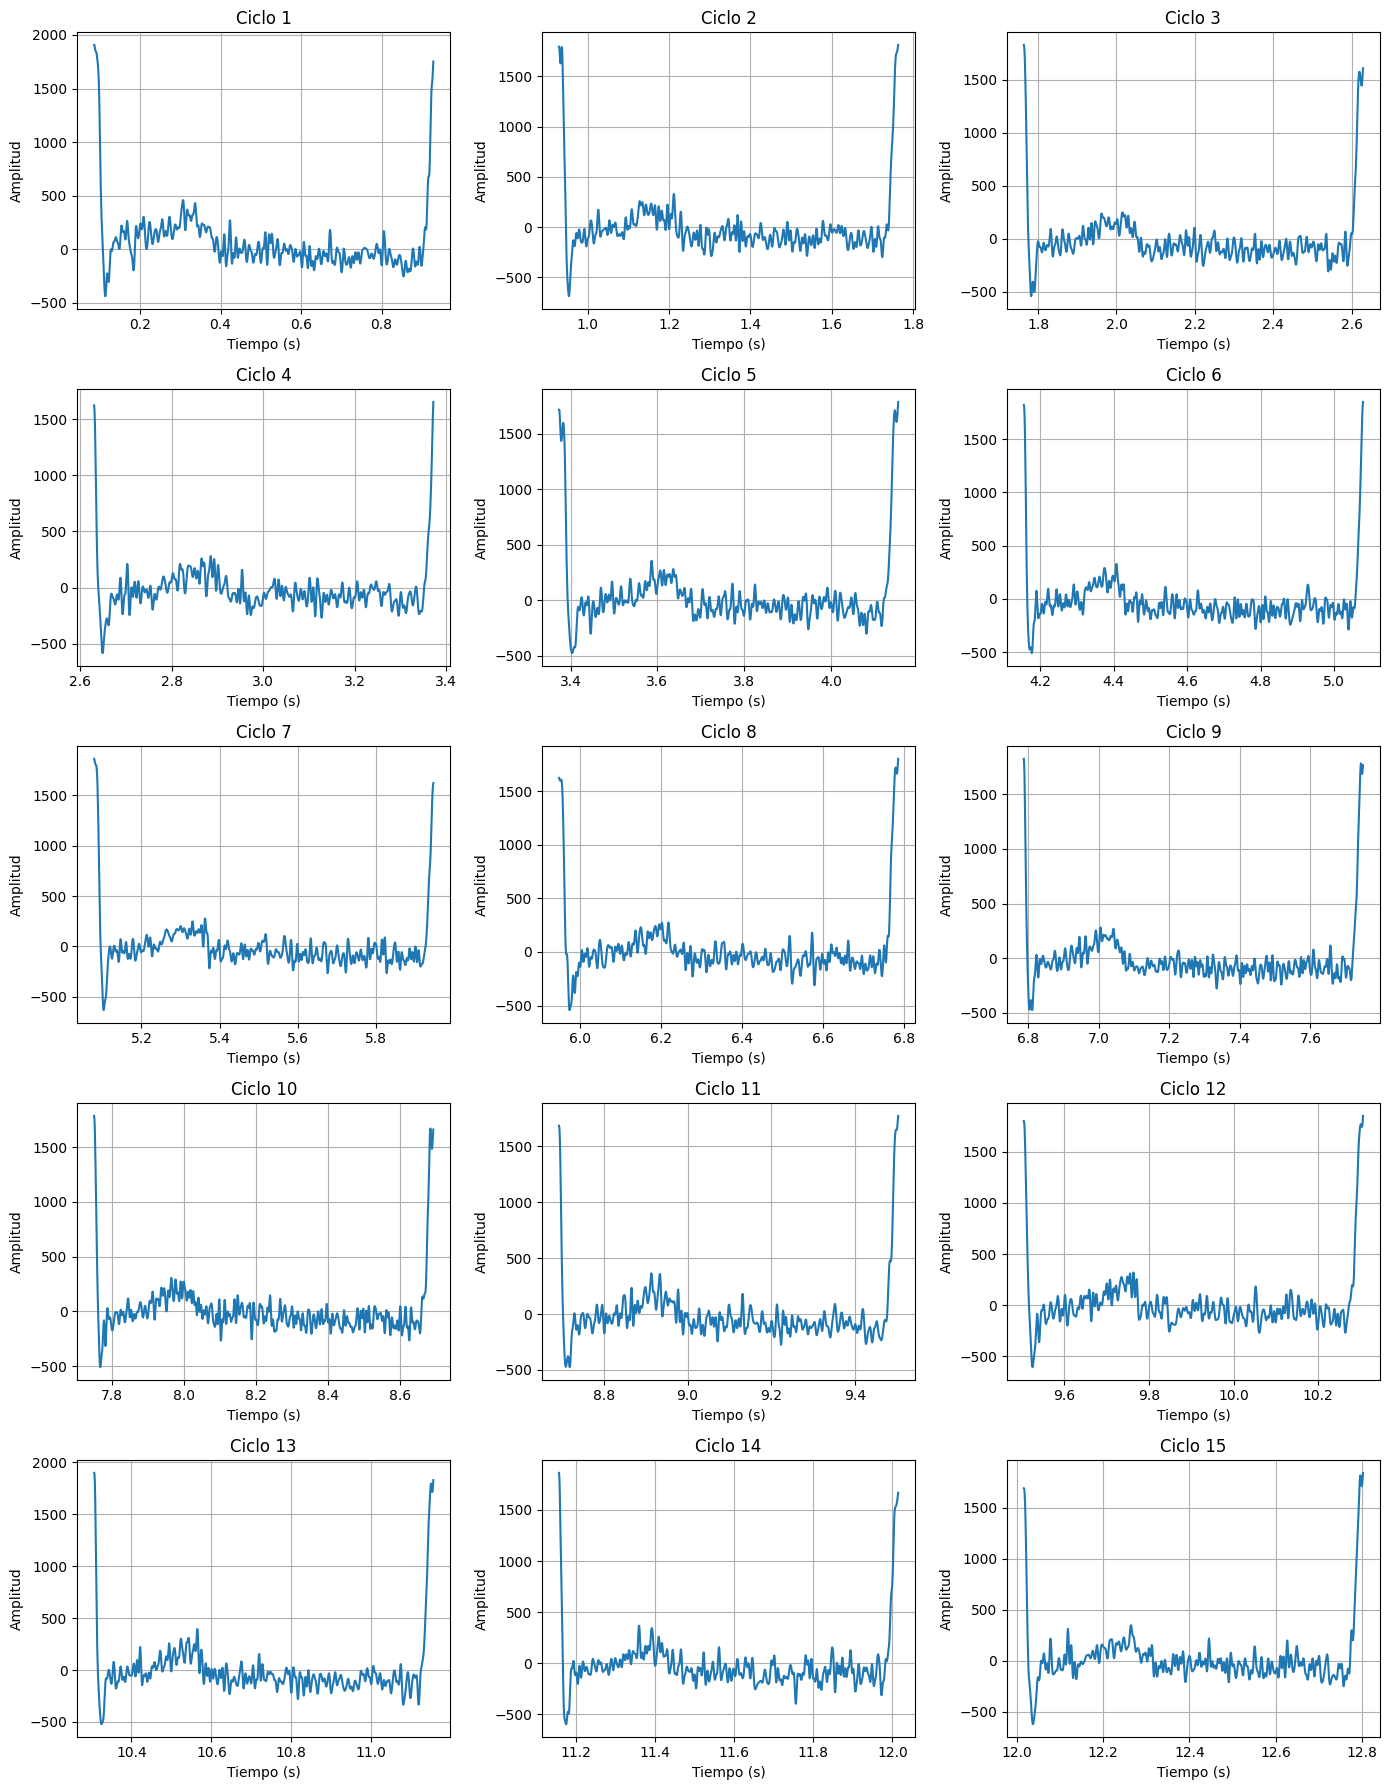

In [9]:
#cada ciclo por separado
plt.figure(figsize=(14, 18))

for i in range(15):
    plt.subplot(5, 3, i + 1)
    plt.plot(tiempos_ciclos[i], ciclos[i])
    plt.title(f"Ciclo {i+1}")
    plt.xlabel("Tiempo (s)")
    plt.ylabel("Amplitud")
    plt.grid(True)

plt.tight_layout()
plt.show()

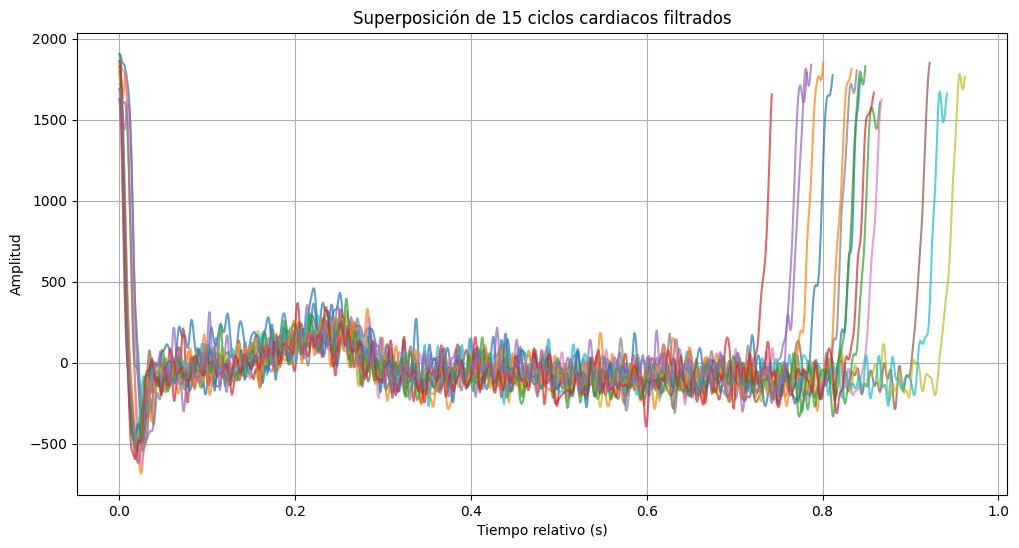

In [10]:
#ahora todos los ciclos completos
plt.figure(figsize=(12, 6))

for i in range(15):
    tiempo_relativo = np.arange(len(ciclos[i])) / Fs
    plt.plot(tiempo_relativo, ciclos[i], alpha=0.7, label=f"C{i+1}")

plt.title("Superposición de 15 ciclos cardiacos filtrados")
plt.xlabel("Tiempo relativo (s)")
plt.ylabel("Amplitud")
plt.grid(True)
plt.show()

Una señal de electrocardiograma se puede considerar estcionaria para un sujeto sano cuando no hay cambios significativos en las propiedades con el tiempo, esto es cuando la media y varianza permanece aproximadamente constante. En un ECG, se puede considerar estacionaria cuando los latidos tienen amplitudes similares, la línea base está cerca de cero y el ritmo cardiaco es practicamente constante.

Inicialmente al ver los gráficos y no los resultlados estadísticos se puede intuir que de los 15 ciclos cardiacos deberán presentar una morfología muy similar entre los diferentes ciclos, especialmente en los picos que son la parte más representativa de un ECG y si las curvas presesentan formas similares y no existen cambios abruptos en amplitud o duración esto nos indicará estabilidad temporal.

Desde un punto de vista estadístico, el promedio y la varianza de cada ciclo nos permiten evaluar si las propiedades de la señal permenecen aproximadamente constantes y si esto sucede podremos concluir que el sistema tiene estabilidad temporal.

Dado que el ECG es una señal fisiológica, no suele ser estrictamente estacionaria en todo el registro, sin embargo si tomamos una señal corta puede que el segmento se comporte como tal. Tomando en cuenta los valores de media y varianza calculados para cada ciclo, la media y la varianza presentan cambios entre ciclos y si es totalmente estricto, no es una señal estacionaria.

Entonces en conclusión y ateniéntonos a la respuesta más estricta a la pregunta, la señal no se puede considerar estacionaria, al menos en todo el tiempo, no obstante, en los 15 ciclos analizados y al tratarse de una señal fisiológica, se podría llegar a decir que la señal es estacionaria o cuasiestacionaria porque tanto valores de promedio como varianza concuerdan con ello ya que las características estadísticas no tienen cambios abruptos, los ciclos cardiacos mantienen una forma y fisiología similar, los promedios son cercanos a uno y la varianza son valores similares (aunque existen algunos valores fuera de rango) [4][5]

# Punto 6
comparaciones entre señales por prueba de t test seleccionando 2 ciclos (2 y 10)

In [64]:
# ciclos
ciclo1= ciclos[0]
ciclo10= ciclos[9]
print(len(ciclo1))

864


### Determinar normalidad de las muestras
Una prueba que sive para determinar si una muestra sigue o no una distribución normal es la prueba de Shapiro-Wilk en muestras pequeñas o medianas. Para determinar entonces si la prueba sigue una distribución normal para poder utilizar la prueba t student, o si no sigue una distribución normal y utilizar pruebas no paramétricas, se utiliza las hipótesis nula y alternativa:
- Ho= los datos provienen de una distribución normal.
- Ha= los datos no provienen de una distribución normal.

Para elegir cuál hipótesis se debe aceptar y cuál rechazar se tiene en cuenta un valor estadístico p-valor que se compara con el valor de significancia α (0.05 = 5% de posible error)
- p≤0.05 --> se rechaza Ho, por lo que los datos no siguen una distribución normal
- p>0.05 --> se acepta Ho, los datos siguen una distribución normal.

In [65]:
p1= shapiro(ciclo1)[1]
p2= shapiro(ciclo10)[1]
def normalidad(ciclo, p):
  if p > 0.05:
     return(f"El ciclo {ciclo} sigue una distribución normal con p={p}")
  else:
    return(f"El ciclo {ciclo} no sigue una distribución normal con p={p}")

print(normalidad(2, p1))
print(normalidad(10, p2))

El ciclo 2 no sigue una distribución normal con p=6.428306789252473e-40
El ciclo 10 no sigue una distribución normal con p=6.518300365347985e-44


Dado que ninguno de los 2 ciclos sigue una distribución normal, no es correcto realizar la prueba t student ya que para realizarla se debe considerar el supuesto de que las muestras tienen una distribución normal. Entonces se deben realizar pruebas no paramétricas para determinar la independencia y diferencias entre los ciclos por medio de la prueba de Spearson y Mann-Whitney respectivamente.

### Prueba Spearman rank
Determina si existe una correlación entre 2 variables cuando los datos no siguen una distribución normal. Si 2 variables son independientes, no deben estar correlacionadas.[6]
- Ho: no existe correlación entre las variables (se acepta cuando p>0.05)
- Ha: Existe correlación entre las variables, no son independientes (se acepta cuando p≤ 0.05)

### Levene´s test
Determina si 2 o más grupos tienen la misma varianza (supuesto de homogeneidad de varianzas) [7]
- Ho: Las varianzas de los grupos son iguales (se acepta cuando p> 0.05)
- Ha= Las varianzas son diferentes entre sí (se acepta cuando p≤ 0.05)

### Mann- whitney
Compara 2 grupos independientes para determinar si sus distribuciones o medianas son diferentes y se usa cuando los datos no siguen una distribución normal y las muestras son independientes. [8]
- Ho: Las medianas de ambos grupos son iguales (se acepta cuando p> 0.05)
- Ha: Las medianas son diferentes (se acepta cuando p≤ 0.05)

In [67]:
# recorte de las señales para que tengan la misma longitud y poderlas comparar
ciclo1= ciclo1[:800]
ciclo10= ciclo10[:800]

# Independencia entre las señales
rho, pind = spearmanr(ciclo1, ciclo10)

# Homocedasticidad
rhov, plev = levene(ciclo1, ciclo10)

# Diferencias entre ciclos
rhomw, pmw = mannwhitneyu(ciclo1, ciclo10)

# ---------------- Independencia Spearman ----------------------------
if pind > 0.05:
  print(f"No hay correlación entre los ciclos ya que p={pind}")
else:
  print(f"Existe una correlación entre los ciclos ya que p={pind}")

# ---------------levene-----------------------------------------------
if plev > 0.05:
  print(f"Las varianzas de ambos grupos son iguales. p={plev}")
else:
  print(f"Las varianzas entre los grupos son difernetes. p={plev}")
# -------------- Mann Whitney -----------------------------------------
if pmw > 0.05:
  print(f"Las medianas de ambos grupos son iguales. p={pmw}")
else:
  print(f"Las medianas de los grupos son diferentes. p={pmw}")

Existe una correlación entre los ciclos ya que p=4.364168518991977e-33
Las varianzas entre los grupos son difernetes. p=3.8136656432294917e-06
Las medianas de los grupos son diferentes. p=2.5476390930783936e-10


Una vez obtenidos los resultados de las pruebas, se descarta definitivamente el uso de la prueba t-test al no cumplir con 3 de los 3 supuestos:
- las muestras no siguen una distribución normal
- Las variazas entre ambos grupos tienen diferencias significativas por lo que no cumplen con hocedasticidad.
- No son muestras independientes ya que tienen correlación entre ellas.

De la prueba de Mann Whitney se concluye que existe una diferencia estadísticamente significativa entre los grupos, confirmando que no se comportan de manera equivalente y presentan variaciones importantes en sus características estadísticas.

# Punto 7 - Prueba de Dickey-Fuller (Estacionariedad)
Esta prueba sirve para analizar series temporales y detectar si la señal tiene una raíz unitaria (si tiene propiedades estadísticas constantes en el tiempo). Si existe una raíz unitaria la serie no es estacionaria, en caso contrario se considera que la serie es estacionaria [9].
- Ho: La serie tiene una raíz unitaria y no es estacionaria.
- Ha: La serie es estacionaria ya que no tiene raíz unitaria.

Al igual que en los casos anteriores, si el valor p dado por la prueba es menor o igual al valor alpha, se rechaza la Ho y se dice que la señal es estacionaria. Si el valor p es mayor que el valor alpha (0.05) se acepta la Ho y la señal no es estacionaria

La prueba puede aplicarse a segmentos o a la señal completa. Al ser una señal ECG es una señal en función del tiempo (serie temporal) y por ende, se puede aplicar la prueba.

In [72]:
senal= np.concatenate([ciclo1,ciclo10])

# Realizar la prueba ADF para los dos ciclos analizados anteriormente
resultado = adfuller(senal)

print("ADF Statistic:", resultado[0])
print("p-valor:", resultado[1])
print("Valores críticos:", resultado[4])

ADF Statistic: -9.93893360655963
p-valor: 2.696597473356403e-17
Valores críticos: {'1%': np.float64(-3.434459072774668), '5%': np.float64(-2.8633549134061376), '10%': np.float64(-2.5677362247386295)}


In [73]:
# Realizando la prueba ADF para los 15 ciclos
señal_total = np.concatenate(ciclos)
resultado = adfuller(señal_total)

print("ADF Statistic:", resultado[0])
print("p-valor:", resultado[1])
print("Valores críticos:", resultado[4])

ADF Statistic: -7.297961550231237
p-valor: 1.3621567413809937e-10
Valores críticos: {'1%': np.float64(-3.4308529676486708), '5%': np.float64(-2.8617622874368585), '10%': np.float64(-2.566888318671982)}


Los resultados de la prueba ADF y Valores críticos ayudan a fortalecer el resultado de estacionariedad o no:
- ADF Statistic: cuando presenta valores negativos, indica qué tan fuerte es la evidencia para rechazar la hipótesis nula.
- Valores críticos: son umbrales teóricos que dependen del nivel de significancia y corresponden a la probabilidad de cometer un error de tipo 1 (falso positivo: rechazar la Ho cuando en realidad era verdadera).
- Si el valor ADF Statistic es más negativo es más negativo que el valor crítico en 2 o más de los porcentajes, se considera que la señal es estacionaria.

En este caso, se obtuvo que tanto para los tramos seleccionados en un inicio como para la señal completa, el ADF es menor que los valores críticos y por ello se puede considerar a la señal ECG como una señal estacionaria en el tiempo.

# Conclusiones

- El preprocesamiento de la señal de la señal ECG mediante el filtrado de pasa altas permitió realizar una eliminación del ofset para que la línea base de la señal se ubicara en un valor cercano a cero y a la vez eliminar el ruido de alta frecuencia que se presnetaba en la señal. Realizar el filtro facilitó el análisis de los ciclos cardíacos sin afectar la información fisiológica que la señal ofrece y se valida de forma visual por medio de gráficas y por análisis estadístico.

- Al calcular los parámetros estadísticos como la media, varianza, RMS y desviación estándar, se demostró un comportamiento relativamente estable entre los distintos ciclos y de lo cual se puede deducir que la señal general posee características que se asocian a un comportamiento relativamente estacionario.

- Para evaluar los supuestos estadísticos se realizaron pruebas de Shapiro-Wilk, Levene Test y Sperman rank que indicaron que no se cumplían las condiciones necesarias para aplicar pruebas paramétricas, es por esto que se utilizó la prueba de Mann-Whitney que permitió identificar las diferencias estadísticamente significativas entre los ciclos analizados.

- La prueba de Dickey-Fuller permitió evaluar la estacionariedad de la señal cuando se evaluaron para señales específicas y para la señal total se observó un comportamiento estacionario con alta confianza que concuerda con un registro para una persona sana.

## REFERENCIAS
[1]«CV Physiology | Electrocardiogram (EKG, ECG)». https://cvphysiology.com/arrhythmias/a009

[2]S. Narayanaswamy, «High resolution electrocardiography», 1 de abril de 2002. https://pmc.ncbi.nlm.nih.gov/articles/PMC1564053/

[3] C. Ortega, «Estadística descriptiva: Qué es, objetivo, tipos y ejemplos», QuestionPro, 23 de septiembre de 2024. https://www.questionpro.com/blog/es/estadistica-descriptiva/

[4]«Onda estacionaria: definición y ejemplos | StudySmarter», StudySmarter ES. https://www.studysmarter.es/resumenes/medicina/audiologia/onda-estacionaria/

[5] E. N. Bruce, Biomedical Signal Processing and Signal Modeling.
New York, NY, USA: Wiley-Interscience, 2001.

[6] C. Spearman, “The proof and measurement of association between two things,”
American Journal of Psychology, vol. 15, no. 1, pp. 72–101, 1904. https://www.jstor.org/stable/1412159?seq=14

[7] Euroinnova Business School,
“Evaluación de homogeneidad de varianzas mediante la prueba de Levene.”  Available: https://tecnologia.euroinnova.com/prueba-de-levene.

[8] numiqo Team,
“Prueba U de Mann-Whitney – Explicación sencilla.” Available: https://numiqo.es/tutorial/mann-whitney-u-test

[9] AcademiaLab, “Prueba de Dickey-Fuller.” Available: https://academia-lab.com/enciclopedia/prueba-de-dickey-fuller/